In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

In [3]:
df= pd.read_csv(r"../../dataset/restaurant.csv")
df= df.dropna(subset=["Cuisines"])
df.isnull().sum()

Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                0
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64

In [4]:
print(df[["Has Table booking","Has Online delivery"]].head())

  Has Table booking Has Online delivery
0               Yes                  No
1               Yes                  No
2               Yes                  No
3                No                  No
4               Yes                  No


In [5]:
table_booking=df["Has Table booking"].value_counts()
table_booking

Has Table booking
No     8384
Yes    1158
Name: count, dtype: int64

In [6]:
online_delivery=df["Has Online delivery"].value_counts()
online_delivery

Has Online delivery
No     7091
Yes    2451
Name: count, dtype: int64

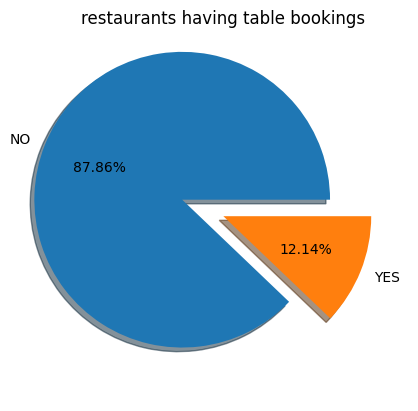

In [7]:
labels=["NO","YES"]
explode=[.3,0]
plt.pie(table_booking,autopct='%.2f%%',explode=explode,labels=labels,shadow=True)
plt.title("restaurants having table bookings")
plt.show()

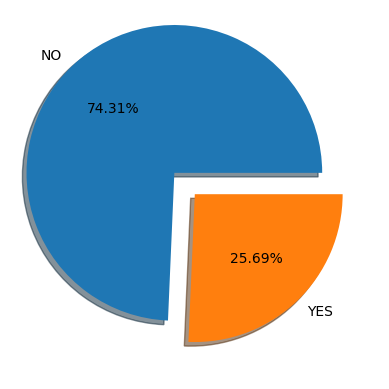

In [8]:
labels=["NO","YES"]
explode=[.2,0]
plt.pie(online_delivery,autopct='%.2f%%',explode=explode,labels=labels,shadow=True)
plt.show()

In [9]:
avg_rating_booking=df.groupby("Has Table booking")["Aggregate rating"].mean()
avg_rating_booking

Has Table booking
No     2.557956
Yes    3.441969
Name: Aggregate rating, dtype: float64

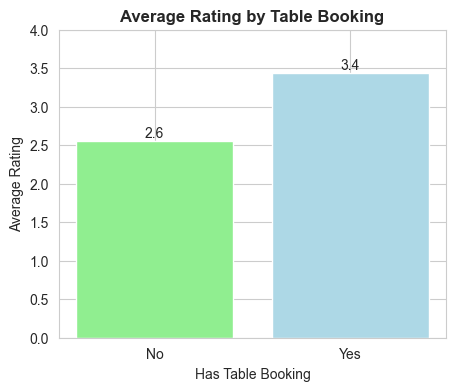

In [24]:
avg_rating_booking = df.groupby("Has Table booking")["Aggregate rating"].mean()
plt.figure(figsize=(5,4))
bars=plt.bar(
    avg_rating_booking.index,
    avg_rating_booking.values,
    color=["lightgreen","lightblue"]
    
)
for bar in bars:
    height=bar.get_height()
    plt.text(bar.get_x()+bar.get_width()/2.,height+0.05,f'{height:.1f}',ha='center')
plt.title("Average Rating by Table Booking",fontweight='bold')
plt.xlabel("Has Table Booking")
plt.ylabel("Average Rating")
plt.ylim(0,4)
plt.show()

In [11]:
avg_rating_delivery=df.groupby("Has Online delivery")["Aggregate rating"].mean()

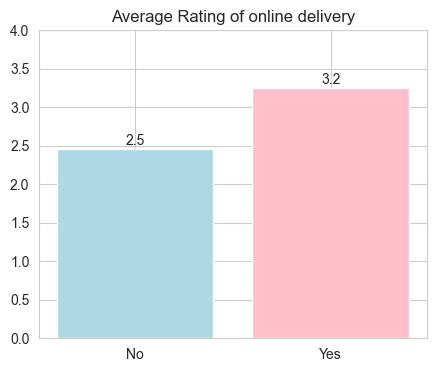

In [30]:
plt.figure(figsize=(5,4))
bars=plt.bar(
    avg_rating_delivery.index,
    avg_rating_delivery.values,
    color=["lightblue","pink"]
)
for bar in bars:
    height=bar.get_height()
    plt.text(bar.get_x()+bar.get_width()/2.,height+0.05,f'{height:.1f}',ha='center')
plt.title("Average Rating of online delivery")
plt.ylim(0,4)
plt.show()